              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1036
           1       0.63      0.52      0.57       373

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC: 0.8407672321881438
                           feature  importance
10     InternetService_Fiber optic    0.396751
25               Contract_Two year    0.169028
11              InternetService_No    0.115870
24               Contract_One year    0.064395
23             StreamingMovies_Yes    0.031382
7                 PhoneService_Yes    0.026557
1                           tenure    0.024297
9                MultipleLines_Yes    0.014939
28  PaymentMethod_Electronic check    0.013720
19                 TechSupport_Yes    0.013361
0                       дорогой разочаровал
1    качественный качественный качественный
2           удобный быстрый хороший быст

c:\Users\Munir\Documents\pythonfiles\neural_churn_prediction\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7199 - loss: 0.6034
Epoch 2/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7345 - loss: 0.5800
Epoch 3/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7345 - loss: 0.5793
Epoch 4/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7345 - loss: 0.5795
Epoch 5/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7345 - loss: 0.5785
Epoch 6/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7345 - loss: 0.5792
Epoch 7/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7345 - loss: 0.5780
Epoch 8/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7345 - loss: 0.5783
Epoch 9/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7345 - loss: 0.5772
Epoch 10/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7345 - loss: 0.5764
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 790us/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 806us/step
=== BASELINE ===
ROC-AUC: 0.841

=== WITH SENTIMENT ===
              precision    rec

✅ Models saved!
✅ feature_importance.csv сохранён!


2026/03/26 23:37:22 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/26 23:37:22 INFO mlflow.store.db.utils: Updating database tables
2026/03/26 23:37:24 INFO mlflow.tracking.fluent: Experiment with name 'churn-prediction-v1' does not exist. Creating a new experiment.
2026/03/26 23:37:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ ROC-AUC: 0.845 logged to MLflow!


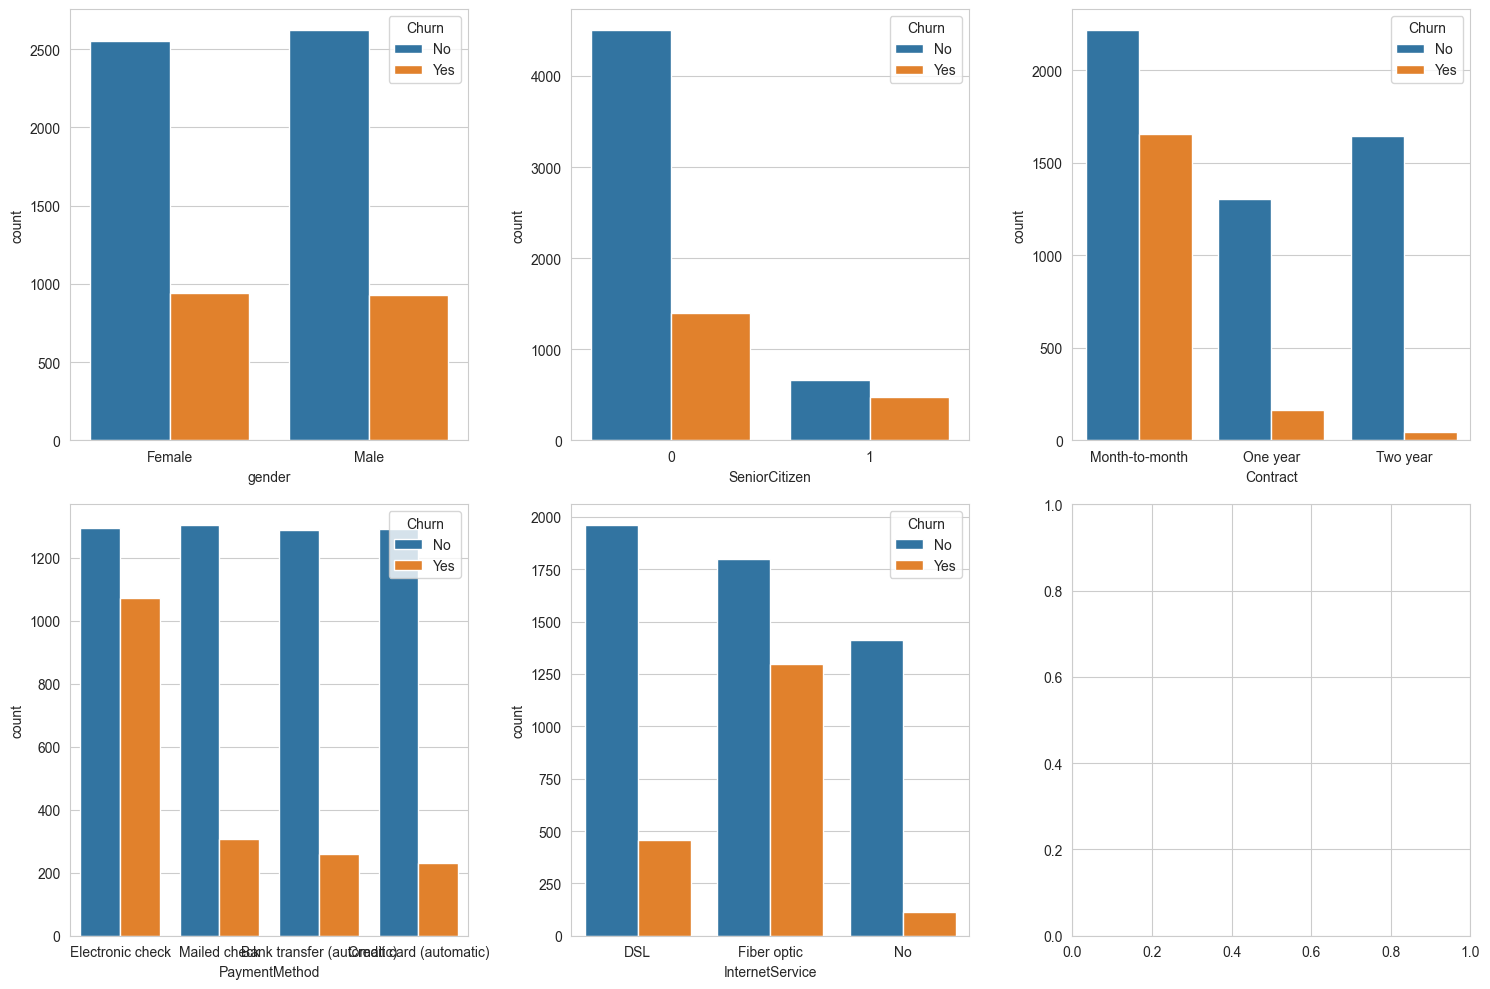

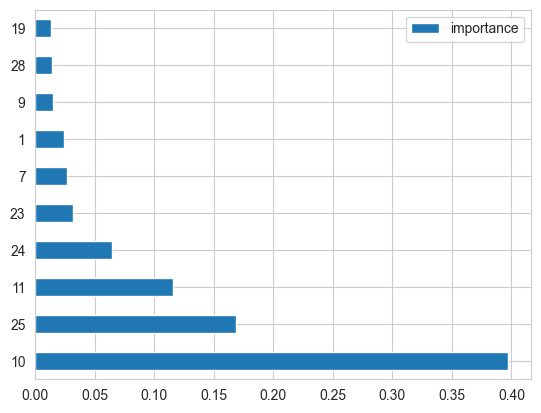

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
# print(df.head())
# print(df.info())
# print(df["Churn"].value_counts(normalize = True))

fig, axes = plt.subplots(2, 3, figsize = (15, 10))

for i, col in enumerate(['gender', 'SeniorCitizen', 'Contract', 'PaymentMethod', 'InternetService']):
    sns.countplot(data=df, x=col, hue='Churn', ax=axes[i//3, i %3])

plt.tight_layout()
plt.savefig('../notebooks/churn_eda.png')
# plt.show()



# Preprocessing
df['Churn'] = (df['Churn'] == 'Yes').astype(int)
df = df.drop('customerID', axis=1)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# Categorical encoding
df = pd.get_dummies(df, drop_first=True)

X = df.drop('Churn', axis=1)  
y = df['Churn']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

xgb = XGBClassifier(random_state=42)
xgb.fit(X_train_scaled, y_train)
y_pred = xgb.predict(X_test_scaled)

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb.predict_proba(X_test_scaled)[:,1]))

importances = pd.DataFrame({'feature': X.columns, 'importance': xgb.feature_importances_}).sort_values('importance', ascending=False)
print(importances.head(10))
importances.head(10).plot(kind='barh')
plt.savefig('../notebooks/feature_importance.png')




# Фейковые отзывы
np.random.seed(42)
positive = ['отличный', 'быстрый', 'качественный', 'хороший', 'удобный']
negative = ['плохой', 'медленный', 'дорогой', 'проблемный', 'разочаровал']

df['review'] = [np.random.choice(positive if np.random.rand()>0.5 else negative, 
                                 np.random.randint(2,5)).tolist() 
                for _ in range(len(df))]
df['review'] = df['review'].apply(' '.join)
print(df['review'].head())




from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense

# Токенизация
tokenizer = Tokenizer(num_words=500)
tokenizer.fit_on_texts(df['review'])
sequences = tokenizer.texts_to_sequences(df['review'])
maxlen = 20
padded_reviews = pad_sequences(sequences, maxlen=maxlen, padding='post')

# Train/test для текста (те же индексы!)
X_text_train = padded_reviews[X_train.index]
X_text_test = padded_reviews[X_test.index]

# Модель (Conv1D для текста!)
text_cnn = Sequential([
    Embedding(500, 32, input_length=maxlen),
    Conv1D(32, 3, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

text_cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
text_cnn.fit(X_text_train, y_train, epochs=10, batch_size=64, verbose=1)


# Получи сентимент
sentiment_train = text_cnn.predict(X_text_train).flatten()
sentiment_test = text_cnn.predict(X_text_test).flatten()

# Добавь к данным
X_train_enhanced = np.column_stack([X_train_scaled, sentiment_train])
X_test_enhanced = np.column_stack([X_test_scaled, sentiment_test])

# XGBoost v2
xgb_v2 = XGBClassifier(random_state=42)
xgb_v2.fit(X_train_enhanced, y_train)
y_pred_v2 = xgb_v2.predict(X_test_enhanced)

print("=== BASELINE ===")
print(f"ROC-AUC: {roc_auc_score(y_test, xgb.predict_proba(X_test_scaled)[:,1]):.3f}")

print("\n=== WITH SENTIMENT ===")
print(classification_report(y_test, y_pred_v2))
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_v2.predict_proba(X_test_enhanced)[:,1]):.3f}")

import pickle
import os
os.makedirs('models', exist_ok=True)

with open('models/feature_names.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)
print("✅ feature_names.pkl сохранён!")

pickle.dump(xgb_v2, open('models/xgb_v2.pkl', 'wb'))
pickle.dump(scaler, open('models/scaler.pkl', 'wb'))
pickle.dump(tokenizer, open('models/tokenizer.pkl', 'wb'))
text_cnn.save('models/text_cnn.h5')

print("✅ Models saved!")


importances.to_csv('feature_importance.csv', index=False)
print("✅ feature_importance.csv сохранён!")

# importances.head(10).to_csv('feature_importance.csv', index=False)
# print("✅ feature_importance.csv saved!")


import mlflow
import mlflow.xgboost
from sklearn.metrics import f1_score  

mlflow.set_experiment("churn-prediction-v1")

with mlflow.start_run(run_name="XGBoost_v2"):
    xgb_v2.fit(X_train_enhanced, y_train)
    y_pred_v2 = xgb_v2.predict(X_test_enhanced)
    
    roc_auc = roc_auc_score(y_test, xgb_v2.predict_proba(X_test_enhanced)[:,1])
    
    mlflow.log_metric("roc_auc", roc_auc)
    mlflow.log_metric("f1_score", f1_score(y_test, y_pred_v2))
    mlflow.log_param("n_estimators", xgb_v2.n_estimators)
    mlflow.log_param("max_depth", xgb_v2.max_depth)
    
    mlflow.xgboost.log_model(xgb_v2, "model")
    
print(f"✅ ROC-AUC: {roc_auc:.3f} logged to MLflow!")

